# Payment Probability Prediction
**Dataset:** 6-Month Loan Recovery Data (Feb 2023 – Jul 2023)  
**Objective:** Predict whether a customer will make a payment in a given month  
**Structure:** Data Cleaning → EDA → Modelling → Conclusions

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = 'Data_6Months.csv'  
df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 348,151 rows × 27 columns


,Account_number,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disbursal_date,disb_amt,tenor,roi,emi,...,final_veri_monthly_income,writeoff_date,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,Pmt_amount,month_end_date
0,1.151000e+11,0.0,4380.0,NCL,PL_SELF,27/01/09 00:00,105000.0,24.0,32.380001,6035.0,...,NaN,01-Jun-11,5884.0,146.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
1,1.152000e+11,0.0,0.0,NCL,PL_SELF,12/09/08 00:00,200000.0,20.0,22.969999,12065.0,...,NaN,01-Sep-10,11844.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
2,1.152000e+11,0.0,4046.0,NCL,PL_SELF,28/12/08 00:00,650000.0,36.0,22.219999,24993.0,...,NaN,01-May-12,24464.0,148.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28


---
## Section 1 — Data Cleaning

In [12]:
df = df_raw.copy()

# 1.1 Date Parsing 
# disbursal_date uses mixed formats (e.g. '27/01/09 00:00', '12/09/08 00:00')
df['disbursal_date']  = pd.to_datetime(df['disbursal_date'],  errors='coerce', dayfirst=True)
# writeoff_date uses format like '01-Jun-11'
df['writeoff_date']   = pd.to_datetime(df['writeoff_date'],   errors='coerce', dayfirst=True)
# month_end_date is already ISO format
df['month_end_date']  = pd.to_datetime(df['month_end_date'],  errors='coerce')

print('Date columns parsed.')

# 1.2 Fix total_outstanding (stored as object/string) 
df['total_outstanding'] = pd.to_numeric(df['total_outstanding'], errors='coerce')

# 1.3 Drop near-fully-null columns (>90% missing) 
# emp_type, industry_type, total_work_exp_months are ~95% null → drop for modelling
high_null_cols = ['emp_type', 'industry_type', 'total_work_exp_months']
df.drop(columns=high_null_cols, inplace=True)
print(f'Dropped high-null columns: {high_null_cols}')

# 1.4 Fill / impute remaining nulls
# Numeric: fill with median (robust to outliers)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical: fill with 'Unknown'
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

# 1.5 Drop rows with no account_number (core identifier) 
before = len(df)
df = df[df['Account_number'].notna()]
print(f'Dropped {before - len(df)} rows with null Account_number')

print(f'\nClean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Date columns parsed.
Dropped high-null columns: ['emp_type', 'industry_type', 'total_work_exp_months']
Dropped 0 rows with null Account_number

Clean dataset: 348,151 rows × 24 columns
Remaining nulls: 302


### 1.6 Data-Quality Summary

In [13]:
quality = pd.DataFrame({
    'dtype':       df_raw.dtypes,
    'null_count':  df_raw.isnull().sum(),
    'null_pct':    (df_raw.isnull().mean() * 100).round(1),
    'n_unique':    df_raw.nunique()
}).sort_values('null_pct', ascending=False)

print('=== DATA QUALITY SUMMARY ===')
print(quality.to_string())


=== DATA QUALITY SUMMARY ===
                             dtype  null_count  null_pct  n_unique
total_work_exp_months      float64      329406      94.6       229
industry_type               object      329415      94.6       119
emp_type                    object      329406      94.6         2
total_outstanding           object      290960      83.6      7391
final_veri_monthly_income  float64      108460      31.2     28709
final_dbr                  float64      105000      30.2      6052
pincode                    float64       87292      25.1      4757
residence_state             object       25430       7.3        28
residence_city              object       25431       7.3       758
cibil_score                float64       10928       3.1       357
source                      object        8015       2.3        38
loan_program_type           object        1559       0.4        14
Pmt_amount                 float64        1154       0.3      5723
emi                        float6

---
## Section 2 — Exploratory Data Analysis

### 2.1 Account Distribution

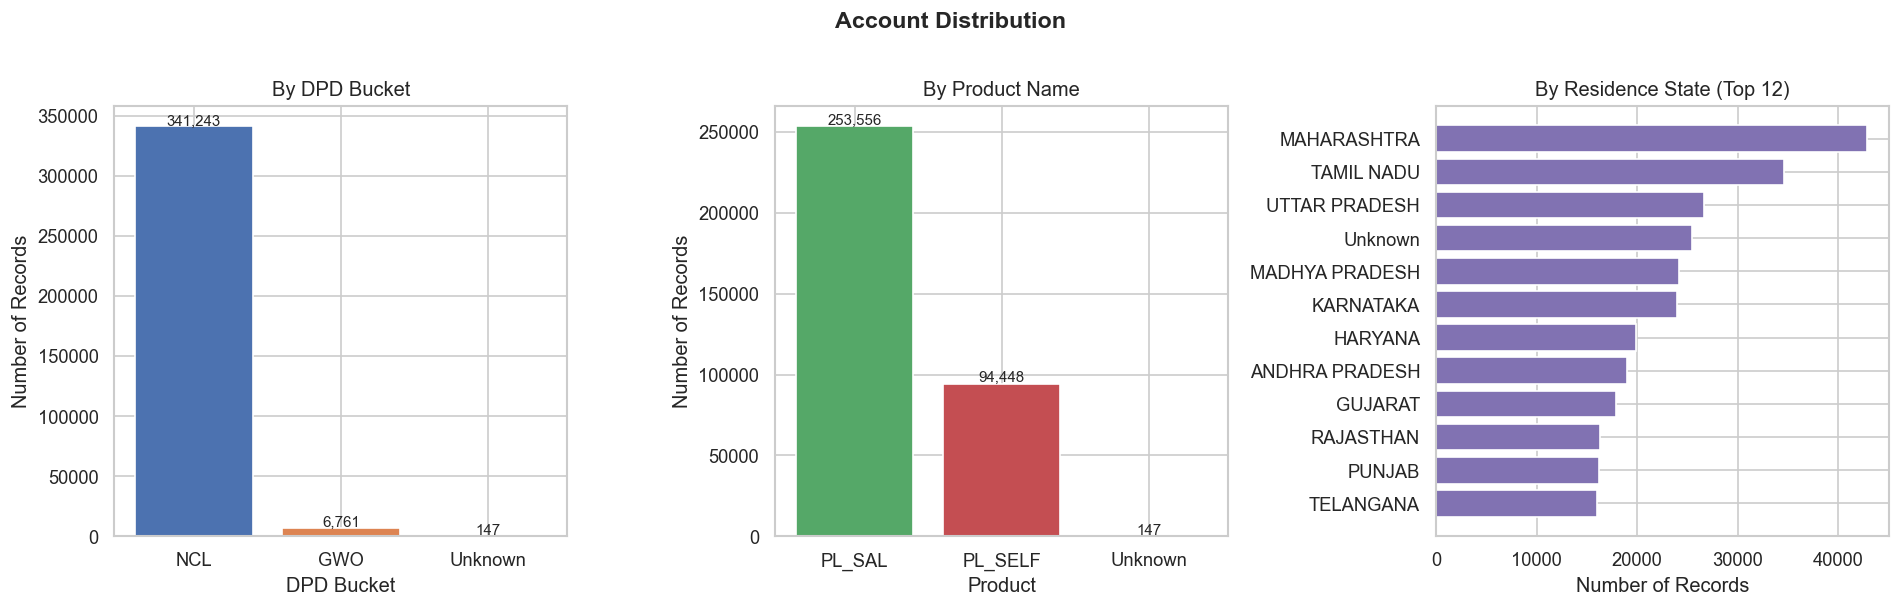

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Account Distribution', fontsize=14, fontweight='bold', y=1.01)

# DPD Bucket
dpd_counts = df['dpd_bucket'].value_counts()
axes[0].bar(dpd_counts.index, dpd_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('By DPD Bucket')
axes[0].set_xlabel('DPD Bucket')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(dpd_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Product Name
prod_counts = df['prod_name'].value_counts()
axes[1].bar(prod_counts.index, prod_counts.values, color=['#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('By Product Name')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Number of Records')
for i, v in enumerate(prod_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Top 12 Residence States
state_counts = df['residence_state'].value_counts().head(12)
axes[2].barh(state_counts.index[::-1], state_counts.values[::-1], color='#8172B2', edgecolor='white')
axes[2].set_title('By Residence State (Top 12)')
axes[2].set_xlabel('Number of Records')

plt.tight_layout()
plt.savefig('plot_account_distribution.png', bbox_inches='tight')
plt.show()

### 2.2 Payment Trends

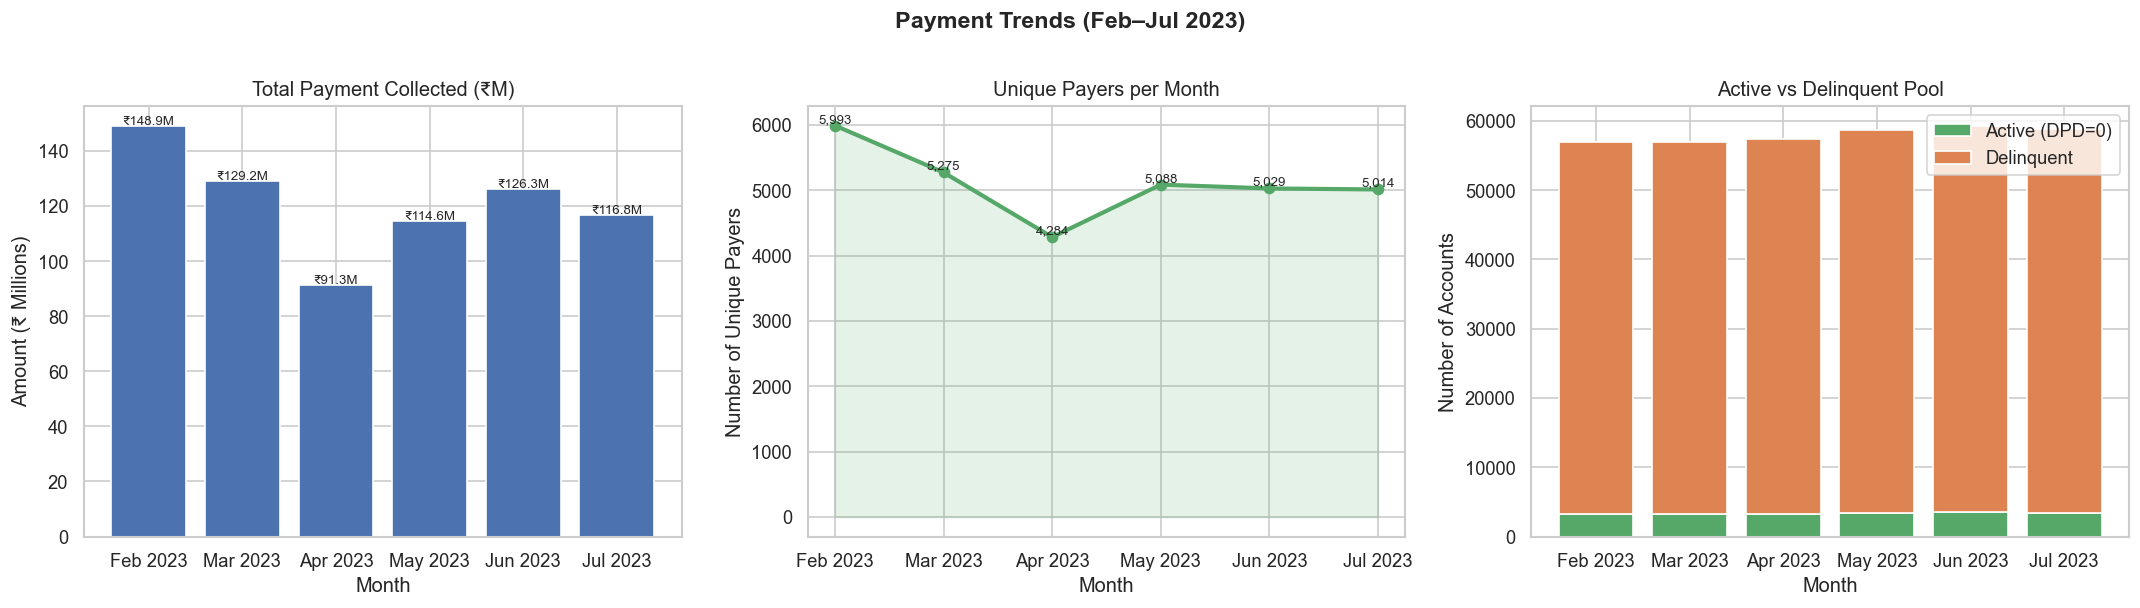

month_label    total_pmt  unique_payers  payer_rate_pct  active_pool  delinquent_pool
   Feb 2023 148919776.83           5993            10.5         3178            53830
   Mar 2023 129239918.49           5275             9.3         3188            53820
   Apr 2023  91310885.14           4284             7.5         3297            54067
   May 2023 114584092.08           5088             8.7         3403            55300
   Jun 2023 126315506.28           5029             8.5         3470            55721
   Jul 2023 116755876.53           5014             8.5         3347            55530


In [15]:
# Aggregate monthly stats
monthly = df.groupby('month_end_date').agg(
    total_pmt      = ('Pmt_amount', 'sum'),
    unique_payers  = ('Account_number', lambda x: (df.loc[x.index, 'Pmt_amount'] > 0).sum()),
    total_accounts = ('Account_number', 'count'),
    active_pool    = ('dpd_days', lambda x: (x == 0).sum()),
).reset_index()

monthly['delinquent_pool'] = monthly['total_accounts'] - monthly['active_pool']
monthly['payer_rate_pct']  = (monthly['unique_payers'] / monthly['total_accounts'] * 100).round(1)
monthly['month_label']     = monthly['month_end_date'].dt.strftime('%b %Y')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Payment Trends (Feb–Jul 2023)', fontsize=14, fontweight='bold', y=1.01)

# Total EMI Collected
axes[0].bar(monthly['month_label'], monthly['total_pmt'] / 1e6, color='#4C72B0', edgecolor='white')
axes[0].set_title('Total Payment Collected (₹M)')
axes[0].set_ylabel('Amount (₹ Millions)')
axes[0].set_xlabel('Month')
for i, v in enumerate(monthly['total_pmt'] / 1e6):
    axes[0].text(i, v + 0.5, f'₹{v:.1f}M', ha='center', fontsize=8)

# Unique Payers
axes[1].plot(monthly['month_label'], monthly['unique_payers'], marker='o', linewidth=2.5, color='#55A868')
axes[1].fill_between(range(len(monthly)), monthly['unique_payers'], alpha=0.15, color='#55A868')
axes[1].set_title('Unique Payers per Month')
axes[1].set_ylabel('Number of Unique Payers')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_label'])
for i, v in enumerate(monthly['unique_payers']):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

# Active vs Delinquent Pool
x = range(len(monthly))
axes[2].bar(x, monthly['active_pool'],    label='Active (DPD=0)',  color='#55A868', edgecolor='white')
axes[2].bar(x, monthly['delinquent_pool'], label='Delinquent',      color='#DD8452', edgecolor='white',
            bottom=monthly['active_pool'])
axes[2].set_title('Active vs Delinquent Pool')
axes[2].set_ylabel('Number of Accounts')
axes[2].set_xlabel('Month')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(monthly['month_label'])
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_payment_trends.png', bbox_inches='tight')
plt.show()

print(monthly[['month_label','total_pmt','unique_payers','payer_rate_pct','active_pool','delinquent_pool']].to_string(index=False))

---
## Section 3 — Modelling

In [16]:
# 3.1 Feature Engineering
df_model = df.copy()

# Target: did the customer pay this month?
df_model['paid'] = (df_model['Pmt_amount'] > 0).astype(int)

# Time-based features
df_model['months_since_disbursal'] = (
    (df_model['month_end_date'] - df_model['disbursal_date']).dt.days / 30
).clip(lower=0)

df_model['months_since_writeoff'] = (
    (df_model['month_end_date'] - df_model['writeoff_date']).dt.days / 30
).clip(lower=0)

# Payment ratio feature
df_model['pmt_to_emi_ratio'] = (df_model['Pmt_amount'] / df_model['emi'].replace(0, np.nan)).fillna(0)

# Encode dpd_bucket: GWO is more severe → 1, NCL → 0
df_model['dpd_bucket_enc'] = (df_model['dpd_bucket'] == 'GWO').astype(int)

# Encode prod_name
df_model['prod_enc'] = LabelEncoder().fit_transform(df_model['prod_name'])

# Encode residence_state (top 15 + 'Other')
top_states = df_model['residence_state'].value_counts().head(15).index
df_model['state_enc'] = df_model['residence_state'].apply(lambda x: x if x in top_states else 'Other')
df_model['state_enc'] = LabelEncoder().fit_transform(df_model['state_enc'])

# Final feature list (excluding leakage features like Pmt_amount itself)
features = [
    'Principal_outstanding', 'dpd_days', 'dpd_bucket_enc',
    'disb_amt', 'tenor', 'roi', 'emi', 'cibil_score',
    'gwo_amt', 'dpd_days_wo', 'total_outstanding', 'final_dbr',
    'months_since_disbursal', 'months_since_writeoff',
    'prod_enc', 'state_enc'
]

X = df_model[features].fillna(0)
y = df_model['paid']

print(f'Target distribution:\n{y.value_counts()}\n')
print(f'Payment rate: {y.mean()*100:.1f}%')

# 3.2 Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

Target distribution:
paid
0    317468
1     30683
Name: count, dtype: int64

Payment rate: 8.8%

Train: 278,520 | Test: 69,631


In [17]:
# 3.3 Logistic Regression (Baseline)
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')
print()
print(classification_report(y_test, lr.predict(X_test), target_names=['No Payment','Payment']))

Logistic Regression ROC-AUC: 0.7933

              precision    recall  f1-score   support

  No Payment       0.97      0.69      0.80     63494
     Payment       0.19      0.78      0.31      6137

    accuracy                           0.69     69631
   macro avg       0.58      0.73      0.56     69631
weighted avg       0.90      0.69      0.76     69631



In [18]:
# 3.4 Decision Tree
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
dt_proba = dt.predict_proba(X_test)[:, 1]
dt_auc   = roc_auc_score(y_test, dt_proba)

print(f'Decision Tree ROC-AUC: {dt_auc:.4f}')
print()
print(classification_report(y_test, dt.predict(X_test), target_names=['No Payment','Payment']))

Decision Tree ROC-AUC: 0.8329

              precision    recall  f1-score   support

  No Payment       0.98      0.70      0.81     63494
     Payment       0.21      0.83      0.33      6137

    accuracy                           0.71     69631
   macro avg       0.59      0.76      0.57     69631
weighted avg       0.91      0.71      0.77     69631



In [19]:
# 3.5 Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f'Random Forest ROC-AUC: {rf_auc:.4f}')
print()
print(classification_report(y_test, rf.predict(X_test), target_names=['No Payment','Payment']))

Random Forest ROC-AUC: 0.8485

              precision    recall  f1-score   support

  No Payment       0.98      0.72      0.83     63494
     Payment       0.22      0.81      0.35      6137

    accuracy                           0.73     69631
   macro avg       0.60      0.77      0.59     69631
weighted avg       0.91      0.73      0.79     69631



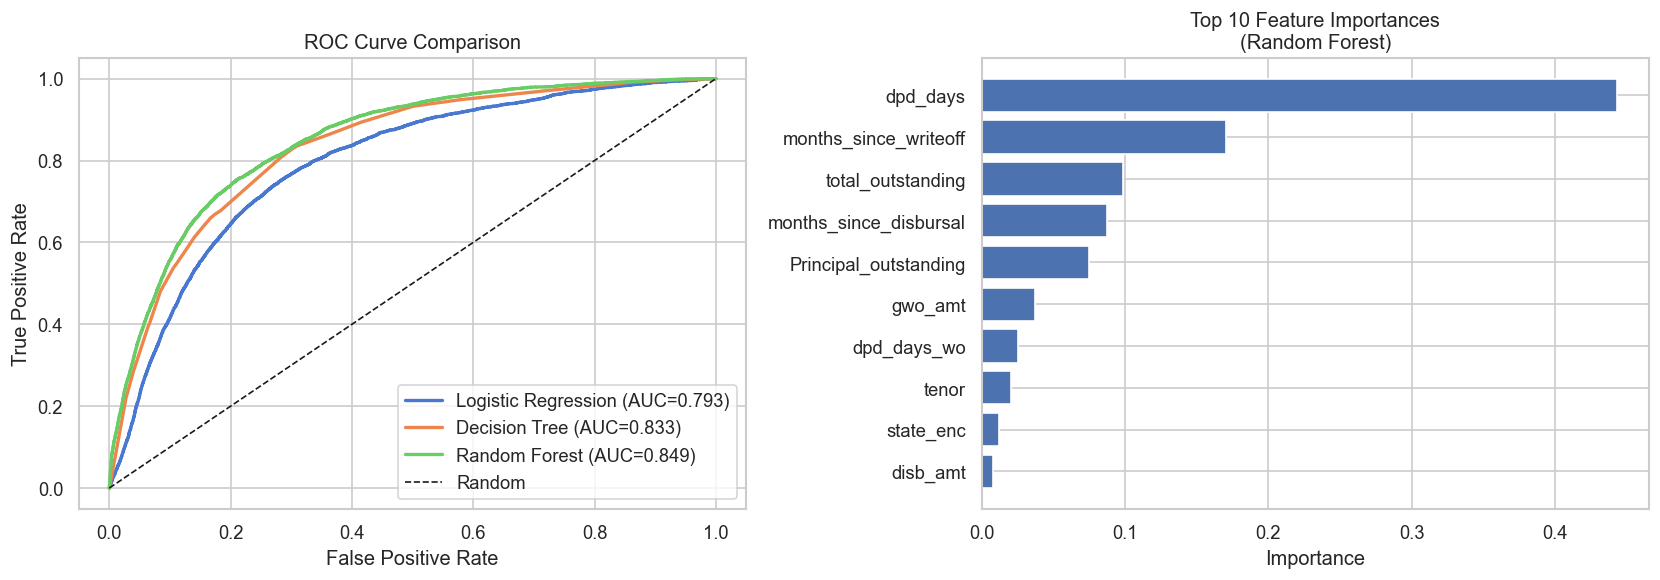


Model Comparison:
  Logistic Regression : 0.7933
  Decision Tree       : 0.8329
  Random Forest       : 0.8485  ← Best


In [20]:
# 3.6 ROC Curve Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for model_name, proba, auc in [
    ('Logistic Regression', lr_proba, lr_auc),
    ('Decision Tree',       dt_proba, dt_auc),
    ('Random Forest',       rf_proba, rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# Feature Importances (Random Forest — best model)
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True).tail(10)
axes[1].barh(feat_imp.index, feat_imp.values, color='#4C72B0', edgecolor='white')
axes[1].set_title('Top 10 Feature Importances\n(Random Forest)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('plot_model_results.png', bbox_inches='tight')
plt.show()

print(f'\nModel Comparison:')
print(f'  Logistic Regression : {lr_auc:.4f}')
print(f'  Decision Tree       : {dt_auc:.4f}')
print(f'  Random Forest       : {rf_auc:.4f}  ← Best')